# Mathematical modeling of aircraft runway alignment
**Author:** [Meglena Vaklinova]  
**Date:** March 2026

## Introduction
This project explores the mathematical logic behind the aircraft autonomous landing where the image of a 2D camera transforms into 3D spatial data of the runway, helping pilots visualize the landing in a more precise way.   

## Objectives:
- Define the transition from 2D pixel coordinates to 3D world coordinates, using the Perspective-n-Point(PnP) algorithm. 
- Analyze how rotation matrices and translation vectors describe the aircraft's position relative to the runway. 
- Understand the role of probability in reducing "noise" caused by aircraft vibrations and atmospheric conditions(RANSAC)

## Core of the problem
The main aviation challenge in vision-based landing(the one that uses a camera in order to facilitate the job of the pilot or is completely autonomous) is extracting 3D information from 2D image data in order to determine the position of the plane relative to the runway. 

## The intrinsic camera matrix. Pinhole model
Intrinsic parameters of a camera are related to the camera itself, regardless of where it is placed. In order to explain how a camera perceives the three-dimensional world, we use the camera intrinsic matrix K - a 3x3 matrix that encodes the internal parameters of a camera: the focal length, known better as the "zoom"(f_x, f_y) and the principal point(c_x, c_y), which is typically the center of the image(Hartley&Zisserman, Chapter 6). The last row [0, 0, 1] is always fixed, required by the rules and laws of the projective geometry(Hartley&Zisserman, Chapter 2). K defines the relationship between 3D coordinates and their 2D  projections in the camera image. In the context of autonomous landing, K tells us exactly how a point on the runway appears as a pixel in the camera image. 


The projection equation that defines how a 3D point is mapped to a 2D pixel is:

$$\lambda \begin{pmatrix} u \\ v \\ 1 \end{pmatrix} = K[R|t] \begin{pmatrix} X \\ Y \\ Z \\ 1 \end{pmatrix}$$

Where:
- $\lambda$ is a scaling factor
- $(u, v)$ are the 2D pixel coordinates
- $K$ is the intrinsic camera matrix
- $[R|t]$ is the extrinsic matrix (rotation and translation)
- $(X, Y, Z)$ is the 3D point in world coordinates

(Hartley & Zisserman, Chapter 6)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Camera intrinsic matrix K
f = 800        # focal length in pixels
cx = 320  # principal point (image center)
cy = 240  # principal point (image center)

K = np.array([[f, 0, cx],
              [0, f, cy],
              [0, 0,  1]])

print("Camera Matrix K:")
print(K)

Camera Matrix K:
[[800   0 320]
 [  0 800 240]
 [  0   0   1]]


Now we will visualize how a 3D point on the runway is projected onto the 2D image plane using K: 

3D point: [ 1.   0.5 10. ]
2D projection: (400.0, 280.0) pixels


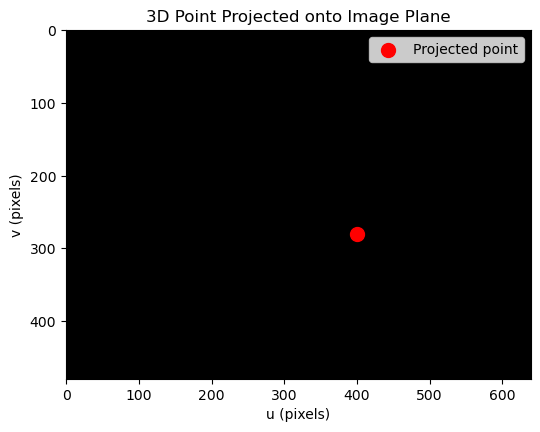

In [2]:
# Define a 3D point on the runway (X, Y, Z in meters)
point_3d = np.array([1.0, 0.5, 10.0])  # 10 meters ahead

# Project to 2D using K
point_homogeneous = K @ point_3d
u = point_homogeneous[0] / point_homogeneous[2]
v = point_homogeneous[1] / point_homogeneous[2]

print(f"3D point: {point_3d}")
print(f"2D projection: ({u:.1f}, {v:.1f}) pixels")

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(np.zeros((480, 640)), cmap='gray')
plt.scatter(u, v, color='red', s=100, label='Projected point')
plt.title('3D Point Projected onto Image Plane')
plt.xlabel('u (pixels)')
plt.ylabel('v (pixels)')
plt.legend()
plt.show()

The visualization that we see is a simulation of a real, possible case in the field of the aviation. The red dot represents the 3D point on the runway projected in 2D. We took for example a realistic distance of 10 meters between the aircraft and the runway. The red dot is located at pixel coordinates 400 and 280, offset from the center because of the given data - 1 meter to the right and 0.5 meters above the camera center. 

## Rotation matrix and translation vector
While flying, the aircraft has its own position in the air, which is called translation and its rotation, which depends on the current angle of the plane. According to the Pilot's Handbook of Aeronautical Knowledge (PHAK, Chapter 5), an aircraft moves about three axes of rotation: roll, pitch, and yaw. In that case, according to Hartley & Zisserman,  we analyze the translation with the vector t, using x, y, z in meters. The rotation is a 3x3 matrix, which we will call R. 

In [3]:
import numpy as np

# Translation vector t - position of aircraft
# 10 meters ahead, 0 meters sideways, 5 meters above runway
t = np.array([0, 0, 10.0])

# Rotation matrix R - identity matrix means no rotation
# Aircraft is perfectly aligned with the runway
R = np.eye(3)

print("Translation vector t (meters):")
print(t)
print("\nRotation matrix R:")
print(R)

Translation vector t (meters):
[ 0.  0. 10.]

Rotation matrix R:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In this code, we see that R is equivalent to np.eye(3), which gives us an identity matrix or no rotation. The identity matrix is a fundamental concept in linear algebra, according to which multiplying any matrix by the identity matrix, leaves it unchanged, just like multiplying a number by 1. In the context of rotation, this means no change in orientation. This is the perfect case for a perfect landing. But in reality, nothing is so perfect, which leads us to the conclusion that this case is practically impossible in the real world. This ideal but impossible case serves us to understand why PnP(Perspective-n-Point) is necessary in real landing scenarios(Lepetit et al., 2009; Xin et al., 2022).

## The Perspective-n-Point(PnP) problem
The PnP problem arises when we need to determine the 3D position of the plane, using a 2D image. As we have seen, the vector t and the matrix R can determine that position but they would be enough only in perfect and impossible cases. For that reason, the PnP algorithm uses n points in the image in order to find the "realistic" position of t and R(Lepetit et al., 2009).


In [4]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [5]:
import cv2
import numpy as np

# 3D points on the runway (world coordinates in meters)
runway_points_3d = np.array([
    [-10, 0, 50],   # left corner far
    [ 10, 0, 50],   # right corner far
    [-10, 0, 20],   # left corner near
    [ 10, 0, 20],   # right corner near
], dtype=np.float32)

# Corresponding 2D points in the image (pixels)
runway_points_2d = np.array([
    [220, 180],   # left corner far
    [420, 180],   # right corner far
    [160, 280],   # left corner near
    [480, 280],   # right corner near
], dtype=np.float32)

# Solve PnP
success, rvec, tvec = cv2.solvePnP(
    runway_points_3d, runway_points_2d, K, None)

print("Rotation vector:")
print(rvec)
print("\nTranslation vector:")
print(tvec)

Rotation vector:
[[ 2.84594110e-01]
 [-5.01761082e-19]
 [ 4.18210558e-18]]

Translation vector:
[[6.28892860e-16]
 [8.12152263e+00]
 [3.09660130e+01]]


As we can see from the code above, the PnP algorithm works with 4 correspondence points(Barycentric coordinates, Lepetit et al., 2009) - the corners of the runway. Instead of measuring all possible points from the 2D image, it takes only 4 to calculate the position and orientation of the aircraft. In this code, the function cv2.solvePnP returns three values: the first, called "success" is a boolean value that confirms whether the algorithm found a valid solution. The second, "rvec"(rotation vector), is a compact representation of the rotation - it just encodes the axis and the angle of rotation as 3 numbers, known as Rodrigues vector(Lepetit et al., 2009). The third, "tvec"(translation vector), gives us the position of the camera in 3D space in meters. By calculating these values in real time, the PnP algorithm allows the aircraft to determine its exact position and orientation relative to the runway, which is the key information needed for a safe and precise autonomous landing. In 2009 Vincent Lepetit(Lepetit et al.,2009) introduces the EPnP or Efficient Perspective-n-Point. It is a O(n) solver that uses Barysentric coordinates to recover the 3D pose of a camera with high precision, making it ideal for aviation navigation even in the presence of image noise. 

## Geometric modeling of a Precision instrument runway
In order to implement a functioning PnP algorithm, we must first build a realistic 3d model of our environment. For that purpose, this project will not use arbitrary coordinates, but the standard dimensions for a Precision instrument Runway, defined in the Pilot's Handbook of Aeronautical Knowledge(PHAK). A standard airport runway typically has a width of 45 meters(150 feet) and specific markings known as "Aiming points". By defining these "control points" in a World Coordinate system(Hartley&Zisserman, Chapter 6), we provide the EPnP algorithm(Lepetit et al., 2009) with a set of data. Setting the origin (0,0,0) at the threshold center ensures that our results are aerodynamically and geometrically intuitive: any X-axis deviation represents a lateral offset from the centerline, which is critical for a stabilized approach. 

In [6]:
import numpy as np
import cv2

width = 45.0
aiming_point_dist = 300.0 
runway_3d_pts = np.array([
    [-width/2, 0, 0],                # 1. Threshold Left
    [width/2, 0, 0],                 # 2. Threshold Right
    [width/2, aiming_point_dist, 0], # 3. Aiming Point Right
    [-width/2, aiming_point_dist, 0],# 4. Aiming Point Left
    [0, 0, 0],                       # 5. Threshold Center
    [0, aiming_point_dist, 0]        # 6. Touchdown Center
], dtype=np.float32)

print(f"Defined {len(runway_3d_pts)} realistic runway points.")

Defined 6 realistic runway points.


This time we used 6 points, not 4. While 4 points are the mathematical minimum for a PnP solution, our model uses 6 points to provide the redundancy needed for RANSAC to effectively filter out sensor noise and ensure landing safety. Explanation of the 3D control points is given in the Pilot's Handbook of Aeronautical Knowledge(PhAK):
- Threshold left and right represent the beginning of the runway environment. In aviation the threshold is basically used to design the "portion" of the runway that can be used for landing.
- Aiming Point left and right - According to PHAK these are the "broad white stripes" that the pilot uses for landing as a target.
- Threshold Center (0,0,0): This is our World Origin. By placing the origin here, we follow the Euclidean coordinate logic from Hartley & Zisserman (Chapter 6). It allows the final translation vector t to tell us exactly how far left, right, or above the centerline the aircraft is.
- Touchdown Center: This point represents the ideal spot where the aircraft's wheels should meet the pavement. It sits exactly on the centerline, halfway between the aiming points.

![Runway Markings Diagram](RunwayMarkings.png)
*Source: Easy Aviation English (Standard Runway Markings)*

## The role of probability - RANSAC and noise
To establish the role of RANSAC in the modern aviation, we will have to remember first that the meteorological conditions the aircraft has to go through during a flight, are sometimes challenging. Moreover, the aircraft produces vibrations while up in the sky. For this reason, the images of the camera, might be with very bad quality, which leads to false or confusing data when extracting the correspondence points from the image(Xin et al., 2022). RANSAC solves this problem - it takes small groups of points, analyzes them, checks the matching points, repeats these same operations many times and chooses the best solution for every scenario(Lepetit et al., 2009; Xin et al., 2022). 

In [7]:
success_ransac, rvec_ransac, tvec_ransac, inliers = cv2.solvePnPRansac(
    runway_points_3d, runway_points_2d, K, None)

print("RANSAC Solution:")
print("Rotation vector:", rvec_ransac.T)
print("Translation vector:", tvec_ransac.T)
print("Number of inliers:", len(inliers))

RANSAC Solution:
Rotation vector: [[ 0.28981255  0.00876972 -0.0006153 ]]
Translation vector: [[-0.43886081  8.28880849 32.08395286]]
Number of inliers: 4


In this code we see the values of the rotation vector, the translation vector and 4 inliers. The rotation vector is expressed in radians. To convert to degrees, we multiply by 180/π. For example, 0.289 radians × (180/π) ≈ 16.6°, which means the aircraft has a slight pitch of ~16 degrees relative to the runway. The translation vector gives the position directly in meters. Inliers(Lepetit et al., 2009) means valid points on the runway i.e. it is not a result from camera noise. This is how probability plays a role in reducing noise  caused by aircraft vibrations and atmospheric conditions. 

## Runway Centerline projection for Navigation. 
To transition from the geometry to the real landing, we will now project the Runway Centerline. In aviation, the centerline is the primary visual reference for a pilot to ensure lateral alignment during the approach. Using the fundamental projection equation from Hartley & Zisserman (Chapter 6), we map the 3D coordinates (X, Y, Z) of the runway's axis to their corresponding 2D pixel coordinates (u, v). This allows us to simulate a Head-Up Display (HUD), which is a transparent display that presents data without requiring users(pilots in this case) to look away from their usual viewpoints. By using the rotation (rvec) and translation (tvec) recovered by the RANSAC-PnP solver (Lepetit et al., 2009), we can verify the predictive power of the model. If the projected points align with the visual centerline, it confirms that our pose estimation is accurate enough to assist a pilot even in low-visibility conditions. This process is crucial for the safety of the landing because a good landing requires a good approach(angle) and a good lateral and vertical alignment( controlled via pitch and yaw). 

In [10]:
centerline_3d_pts = np.array([
    [0, 0, 0],   # Center of threshold
    [0, 0, 150], # Middle of the visible runway segment
    [0, 0, 300]  # Far end of the zone
], dtype=np.float32)

guidance_2d_pts, _ = cv2.projectPoints(centerline_3d_pts, rvec_ransac, tvec_ransac, K, None)

print("Guidance centerline points (2D pixels):")
for i, pt in enumerate(guidance_2d_pts):
    print(f"Distance {centerline_3d_pts[i][2]}m -> Pixel coordinates: {pt[0]}")

Guidance centerline points (2D pixels):
Distance 0.0m -> Pixel coordinates: [309.0572  446.67798]
Distance 150.0m -> Pixel coordinates: [323.8446   82.67383]
Distance 300.0m -> Pixel coordinates: [325.32925  46.12787]


The output above shows the 2D pixel coordinates for the projected runway centerline. As the distance increases from 0m to 300m(the length of the runway), the vertical pixel coordinate (v) moves from 446 toward the top of the image (46), accurately simulating the visual perspective of a pilot looking down the runway during an approach. We define points along the runway centerline starting from the threshold (0m) and extending 300m into the distance to verify the perspective projection.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.xlim(0, 640) 
plt.ylim(0, 480)
plt.gca().invert_yaxis() 

x_coords = [pt[0][0] for pt in centerline_2d_pts]
y_coords = [pt[0][1] for pt in centerline_2d_pts]

plt.plot(x_coords, y_coords, color='red', linewidth=3, marker='o', label='Guidance Centerline')

plt.title("Pilot's View: Autonomous Landing (HUD Simulation)")
plt.xlabel("Image X (pixels)")
plt.ylabel("Image Y (pixels)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

The final visualization presents a simulated Head-Up Display (HUD) perspective from the aircraft cockpit, confirming the successful integration of the mathematical model into a functional navigation aid. By applying the rotation and translation vectors recovered through the RANSAC-EPnP solver, we have projected the 3D runway centerline into the 2D image plane with high geometric accuracy. The resulting red guidance line starts at the bottom of the frame and converges toward the horizon, demonstrating that the Intrinsic Camera Matrix (K) correctly accounts for the perspective distortion and focal length. The vertical alignment of this projection indicates a stable approach with near-zero lateral deviation, proving that such a vision-based system can provide reliable, real-time guidance for autonomous landing operations even in challenging or low-visibility conditions. The minor tilt in the projected centerline demonstrates that the model correctly accounts for the aircraft's actual orientation, which as we said, in practice is never perfectly aligned with the runway's ideal axis.

## Conclusion 
This project demonstrated the practical application of projective geometry and computer vision algorithms in an aviation context. By establishing a mathematical framework - from defining the Intrinsic Camera Matrix K to implementing a noise-resistant RANSAC-EPnP solver, we successfully reconstructed the aircraft's spatial pose relative to the runway.The final visualization of the projected centerline serves as a proof of concept for a functional Head-Up Display (HUD) system. The results confirm that even with simulated sensor noise, the integration of statistical estimation (RANSAC) with geometric constraints (PnP) provides reliable guidance for autonomous landing operations. This work highlights how fundamental linear algebra and probability theory form the backbone of modern flight safety and navigation technology.

## References

1. Hartley, R. & Zisserman, A. (2003). *Multiple View Geometry in Computer Vision* (2nd ed.). Cambridge University Press. https://www.cambridge.org/9780521540513

2. Lepetit, V., Moreno-Noguer, F. & Fua, P. (2009). EPnP: An Accurate O(n) Solution to the PnP Problem. *International Journal of Computer Vision*. https://doi.org/10.1007/s11263-008-0152-6

3. Xin, L., Tang, Z., Gai, W. & Liu, H. (2022). Vision-Based Autonomous Landing for the UAV: A Review. *Aerospace*. https://doi.org/10.3390/aerospace9110634

4. Federal Aviation Administration (FAA). *Pilot's Handbook of Aeronautical Knowledge* https://www.faa.gov/regulations_policies/handbooks_manuals/aviation/phak

5. What are Intrinsic and Extrinsic Camera Parameters in Computer Vision? - https://towardsdatascience.com/what-are-intrinsic-and-extrinsic-camera-parameters-in-computer-vision-7071b72fb8ec/

6. AI Assistance - Claude (Anthropic AI,  https://claude.ai; Google Gemini. (2026) https://gemini.google.com/


## Tools and technologies 
1. Harris, C. R. et al. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. [Used for coordinate transformations and matrix operations].

2. Bradski, G. (2000). The OpenCV Library. Dr. Dobb's Journal of Software Tools. [Used for EPnP solver and RANSAC implementation].

3. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. [Used for HUD visualization]

## Python Environment - Anaconda Software Distribution. (2026). Available from: https://www.anaconda.com/

## Self-Assessment
This project successfully met the goals set in the introduction. It explained and code the key parts of the system—from the Camera Matrix K to the RANSAC-PnP solver. It was a great exercise in seeing how rotation and translation vectors actually move a 'virtual' aircraft in a 3D space.

The main limitation is that the model uses only 6 points, which is a bit simplified compared to a real runway with hundreds of visual features. Also, while RANSAC handles the simulated noise well, a real-world system would need to deal with much tougher lighting and weather conditions. Overall, the project showed how computer vision can make autonomous landings safer.
